In [1]:
EPOCHS = None; learnRate = None                                                 # epochN = 300, learnRate = 0.0005/0.0010/0.0015/0.0020/0.0025
import glob
import zipfile
fileList = glob.glob('*.zip')
zip_ref = zipfile.ZipFile(fileList[0], 'r');
zip_ref.extractall()
zip_ref.close()
w = fileList[0].split('.'); project = w[-2]
print('프로젝트:',project)


프로젝트: 0926_ympark


In [2]:
import os
import sys
import time
import glob
import random
import pickle
import numpy as np

# TensorFlow / KERAS
import tensorflow as tf
import tensorflow.keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, Dropout, Flatten, Dense, Input
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

# Imaging
import cv2 as cv
import matplotlib.pyplot as plt

print('OpenCV Version:       ', cv.__version__)
print('NumPy Version:        ', np.__version__)
print('Tensorflow Version:   ', tf.__version__)
print('Keras Version:        ', tensorflow.keras.__version__)
print('Python Version:       ', sys.version)


OpenCV Version:        4.12.0
NumPy Version:         2.0.2
Tensorflow Version:    2.19.0
Keras Version:         3.10.0
Python Version:        3.12.11 (main, Jun  4 2025, 08:56:18) [GCC 11.4.0]


In [3]:
# 이미지 데이터 조향각 추출

with open(f'{project}/_{project}.pickle', 'rb') as f:                           # pickle 파일
    x_exam_Image = pickle.load(f)                                               # 시험(Test) 이미지 파일 이름 리스트
    x_valid_Image = pickle.load(f)                                              # 평가(Valid) 이미지 파일 이름 리스트
    x_train_Image = pickle.load(f)                                              # 훈련(Train) 이미지 파일 이름 리스트
    p = pickle.load(f)                                                          # 파라메터 리스트
if EPOCHS == None: EPOCHS = p[0]                                                # 학습회수
if learnRate == None: learnRate = p[1]                                          # 학습 비율 0.0005/0.0010/0.0015/0.0020/0.0025
#-------------------------------------------------------------------------------
y_exam_Angle=[]
y_valid_Angle=[]
y_train_Angle = []
for f in x_exam_Image:                                                          # 시험용 이미지 파일 이름에서 각도값
    y_exam_Angle.append(int(f[-7:-4]))
for f in x_valid_Image:                                                         # 평가용 이미지 파일 이름에서 각도값
    y_valid_Angle.append(int(f[-7:-4]))
for f in x_train_Image:                                                         # 훈련용 이미지 파일 이름에서 각도값
    y_train_Angle.append(int(f[-7:-4]))

print('학습 회수:',EPOCHS,)
print('학습 비율', learnRate)
print('시험 이미지 개수:',len(x_exam_Image))
print('평가 이미지 개수:',len(x_valid_Image))
print('훈련 이미지 개수:',len(x_train_Image))


학습 회수: 300
학습 비율 0.001
시험 이미지 개수: 7
평가 이미지 개수: 213
훈련 이미지 개수: 857


In [4]:
# Nvidia CNN 모델 구성 -----------------------------------------------------
def nvidia_model(lr=learnRate):

    model = Sequential(name='Nvidia_Model')

    # elu=Expenential Linear Unit, similar to leaky Relu
    # skipping 1st hiddel layer (nomralization layer), as we have normalized the data
    # Convolution Layers

    model.add(Input(shape=(66, 200, 3)))
    model.add(Conv2D(24, (5, 5), strides=(2, 2), activation='elu'))
    model.add(Conv2D(36, (5, 5), strides=(2, 2), activation='elu'))
    model.add(Conv2D(48, (5, 5), strides=(2, 2), activation='elu'))
    model.add(Conv2D(64, (3, 3), activation='elu'))
    #model.add(Dropout(0.2))
    model.add(Conv2D(64, (3, 3), activation='elu'))

    # Fully Connected Layers
    model.add(Flatten())
    model.add(Dropout(0.2))
    model.add(Dense(100, activation='elu'))
    model.add(Dense(50, activation='elu'))
    model.add(Dense(10, activation='elu'))

    # output layer: turn angle (from -99 ~ +99  0 is straight, -99 turn left, +99 turn right)
    model.add(Dense(1))

    # since this is a regression problem not classification problem,
    # we use MSE (Mean Squared Error) as loss function
    # optimizer = Adam(lr=1e-3)  # lr is learning rate
    optimizer = Adam(learning_rate=lr)  # 학습율 설정
    model.compile(loss='mse', optimizer=optimizer)

    return model

# 학습 데이터 생성 -----------------------------------------------------------
def batchGen(imageList, angleList, batchSize):

    while True:
        imageBatch = []
        angleBatch = []

        for i in range(batchSize):
            t = f'{project}/'+ imageList[i]
            image = cv.imread(t)
            angle = angleList[i]

            image = image/255 # 255 로 나누어 0 - 0.999 로 데이터 표시 방법 변경
            imageBatch.append(image)
            angleBatch.append(angle)

        yield(np.asarray(imageBatch), np.asarray(angleBatch))


In [7]:
# 모델 학습 ----------------------------------------------
def learnProc():

    startLearn = time.time()   #  학습 시작 시각
    cPCallback = tensorflow.keras.callbacks.ModelCheckpoint(filepath=f'./_{project}_model_check.keras', verbose=1, save_best_only=True)
    hist = model.fit(batchGen(x_train_Image, y_train_Angle, batchSize=len(x_train_Image)),
                     steps_per_epoch=30,
                     epochs=10,                # 학습 회수이며 디폴트로 3 회
                     validation_data = batchGen(x_valid_Image, y_valid_Angle, batchSize=len(x_valid_Image)),
                     validation_steps=200,
                     verbose=1,               # 학습 시간을 오래 기다려야 하므로 막대 그래프로 진행상황 표시
                     shuffle=True,            # 주어진 데이터를 랜덤하게 재배치.
                     callbacks=[cPCallback])

    # TensorFlow Lite 변환기 생성
    converter = tf.lite.TFLiteConverter.from_keras_model(model)

    # 양자화 (선택 사항)
    # converter.optimizations = [tf.lite.Optimize.DEFAULT]

    # 변환 및 저장
    tflite_model = converter.convert()

    # TensorFlow Lite 모델 저장
    open(f'./_{project}_model_final.tflite', 'wb').write(tflite_model)
    model.save(f'./_{project}_model_final.keras')   # 학습모델 저장

    endLearn = time.time()                   # 학습 종료 시각
    timeLearn = int(endLearn - startLearn)   # 학습 소요 시간

    t = f'{int(timeLearn/60):4d} 분   {int(timeLearn%60):2d} 초'
    print('학습 소요시간:',t)

    return(hist.history)   # 딕셔너리 데이터로 변환하여 반환


Model: "Nvidia_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_5 (Conv2D)               │ (None, 31, 98, 24)     │         1,824 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 14, 47, 36)     │        21,636 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 5, 22, 48)      │        43,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 3, 20, 64)      │        27,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 1, 18, 64)      │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 100)            │       115,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 50)             │         5,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 10)             │           510 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 252,219 (985.23 KB)

 Trainable params: 252,219 (985.23 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 721ms/step - loss: 524.8610
Epoch 1: val_loss improved from inf to 95.38857, saving model to ./_0926_ympark_model_check.keras
30/30 ━━━━━━━━━━━━━━━━━━━━ 66s 2s/step - loss: 518.4539 - val_loss: 95.3886
Epoch 2/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 705ms/step - loss: 50.4525
Epoch 2: val_loss improved from 95.38857 to 39.67709, saving model to ./_0926_ympark_model_check.keras
30/30 ━━━━━━━━━━━━━━━━━━━━ 63s 2s/step - loss: 50.0110 - val_loss: 39.6771
Epoch 3/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 656ms/step - loss: 15.0715
Epoch 3: val_loss improved from 39.67709 to 24.76497, saving model to ./_0926_ympark_model_check.keras
30/30 ━━━━━━━━━━━━━━━━━━━━ 58s 2s/step - loss: 15.0057 - val_loss: 24.7650
Epoch 4/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 548ms/step - loss: 8.8596
Epoch 4: val_loss improved from 24.76497 to 18.58766, saving model to ./_0926_ympark_model_check.keras
30/30 ━━━━━━━━━━━━━━━━━━━━ 54s 2s/step - loss: 8.8329 - val_loss: 18.5877
Epoch 5/10
30/30 ━━━━

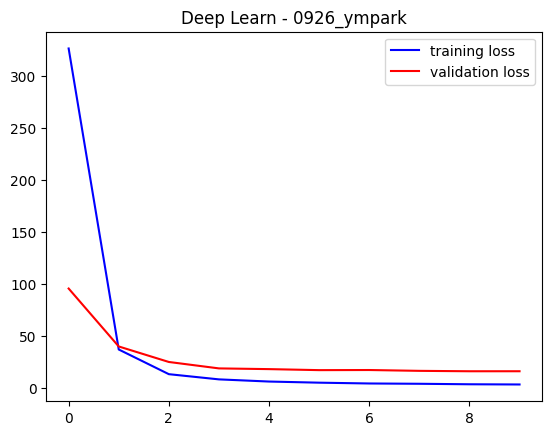

In [8]:
model = nvidia_model()              # NVIDIA 모델
model.summary()
history = learnProc()               # 학습 시작

plt.plot(history['loss'], color='blue')
plt.plot(history['val_loss'],color='red')
plt.legend(['training loss','validation loss'])
plt.title(f'Deep Learn - {project}')
plt.savefig(f'./_{project}_Plt.png')
plt.show()


✅ sequence.csv 파일 저장 완료: /content/sequence.csv
   sequence_id  value
0            0      2
1            1      2
2            2      1
3            3      0
4            4     -2


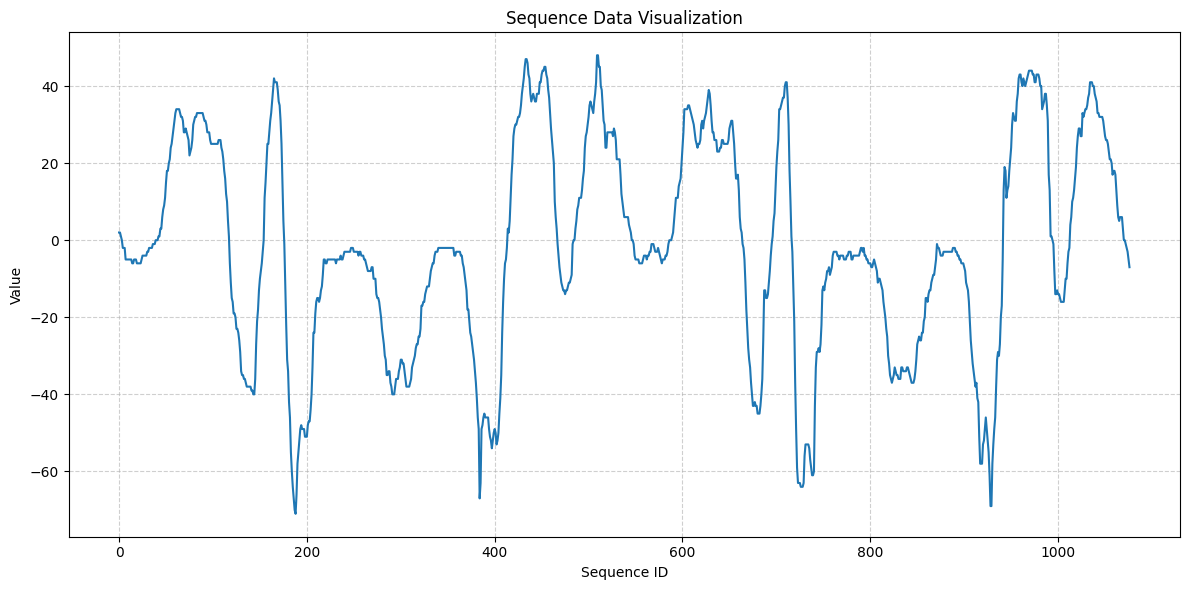

In [16]:
import os
import re
import pandas as pd
import matplotlib.pyplot as plt

# 이미지 파일이 들어있는 폴더 경로
folder_path = "/content/0926_ympark"   # Colab에 업로드한 경우 경로 지정

# 파일명 패턴 정규식 (예: P0000__+25.png)
pattern = re.compile(r"P(\d{4})__([+-]?\d+)\.png")

data = []

# 폴더 내 모든 파일 탐색
for filename in os.listdir(folder_path):
    match = pattern.match(filename)
    if match:
        seq_num = int(match.group(1))   # 네 자리 숫자
        value = int(match.group(2))     # 부호 포함 정수
        data.append([seq_num, value])

import os
import re
import pandas as pd

# 이미지 파일이 들어있는 폴더 경로
folder_path = "/content/0926_ympark"   # Colab에 업로드한 경우 경로 지정

# 파일명 패턴 정규식 (예: P0000__+25.png)
pattern = re.compile(r"P(\d{4})__([+-]?\d+)\.png")

data = []

# 폴더 내 모든 파일 탐색
for filename in os.listdir(folder_path):
    match = pattern.match(filename)
    if match:   # <-- 들여쓰기 주의 (for 안에서 4칸 들여쓰기, if 안에서 8칸 들여쓰기)
            seq_num = int(match.group(1))   # 네 자리 숫자
            value = int(match.group(2))     # 부호 포함 정수
            data.append([seq_num, value])

# DataFrame 생성
df = pd.DataFrame(data, columns=["sequence_id", "value"])
df = df.sort_values(by="sequence_id").reset_index(drop=True)

# sequence.csv로 저장
csv_path = "/content/sequence.csv"
df.to_csv(csv_path, index=False, encoding="utf-8")

print("✅ sequence.csv 파일 저장 완료:", csv_path)
print(df.head())  # 일부 미리보기

# 시각화
plt.figure(figsize=(12, 6))
plt.plot(df["sequence_id"], df["value"], marker="", linestyle="-")
plt.title("Sequence Data Visualization")
plt.xlabel("Sequence ID")
plt.ylabel("Value")
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()


# 저장
output_img = "/content/sequence_timeseries.png"
plt.savefig(output_img, dpi=300, bbox_inches="tight")
plt.close()



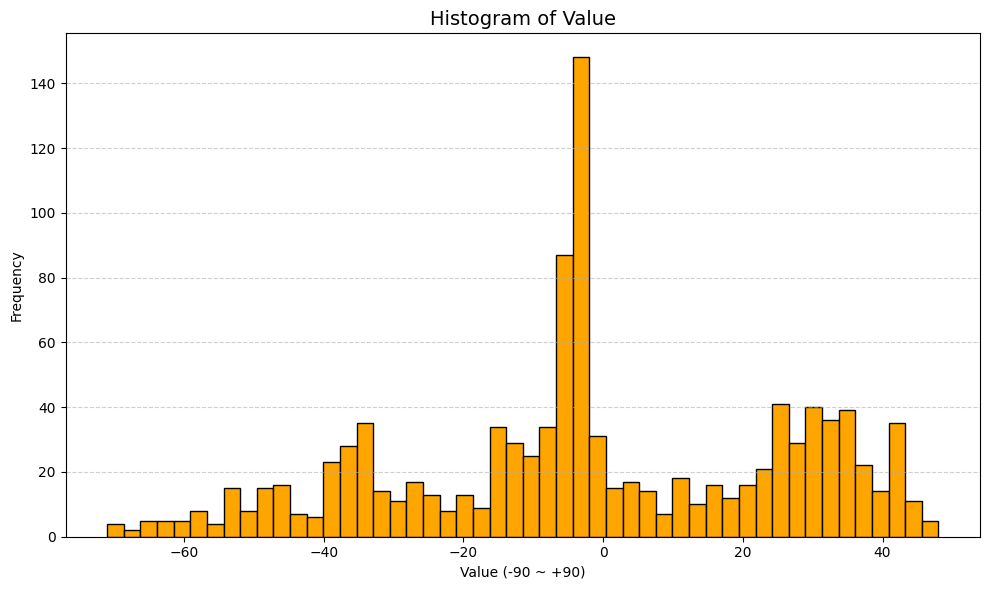

<Figure size 640x480 with 0 Axes>

In [18]:
# value에 대한 히스토그램
plt.figure(figsize=(10,6))
plt.hist(df["value"], bins=50, color="orange", edgecolor="black")
plt.title("Histogram of Value", fontsize=14)
plt.xlabel("Value (-90 ~ +90)")
plt.ylabel("Frequency")
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()
plt.tight_layout()
plt.show()


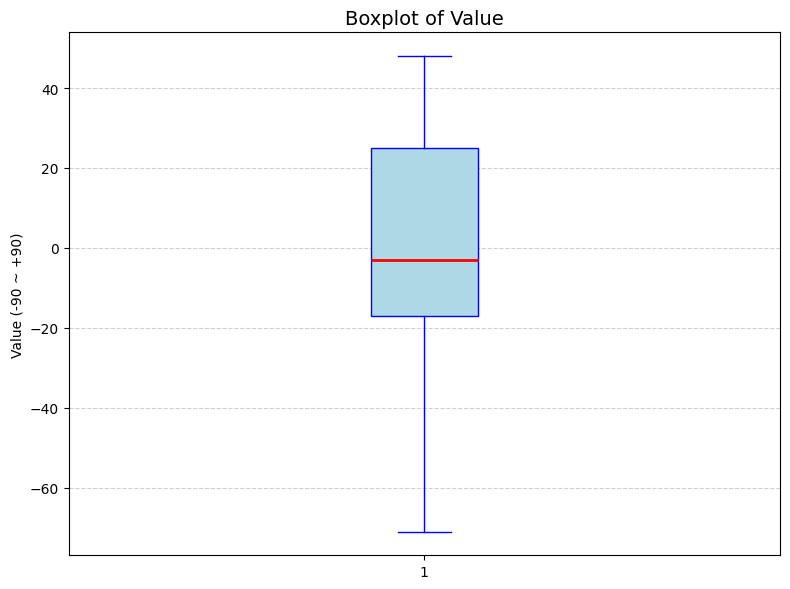

In [20]:






# 박스플롯 그리기
plt.figure(figsize=(8,6))
plt.boxplot(df["value"], vert=True, patch_artist=True,
            boxprops=dict(facecolor="lightblue", color="blue"),
            medianprops=dict(color="red", linewidth=2),
            whiskerprops=dict(color="blue"),
            capprops=dict(color="blue"),
            flierprops=dict(marker="o", color="green", alpha=0.5))
plt.title("Boxplot of Value", fontsize=14)
plt.ylabel("Value (-90 ~ +90)")
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()


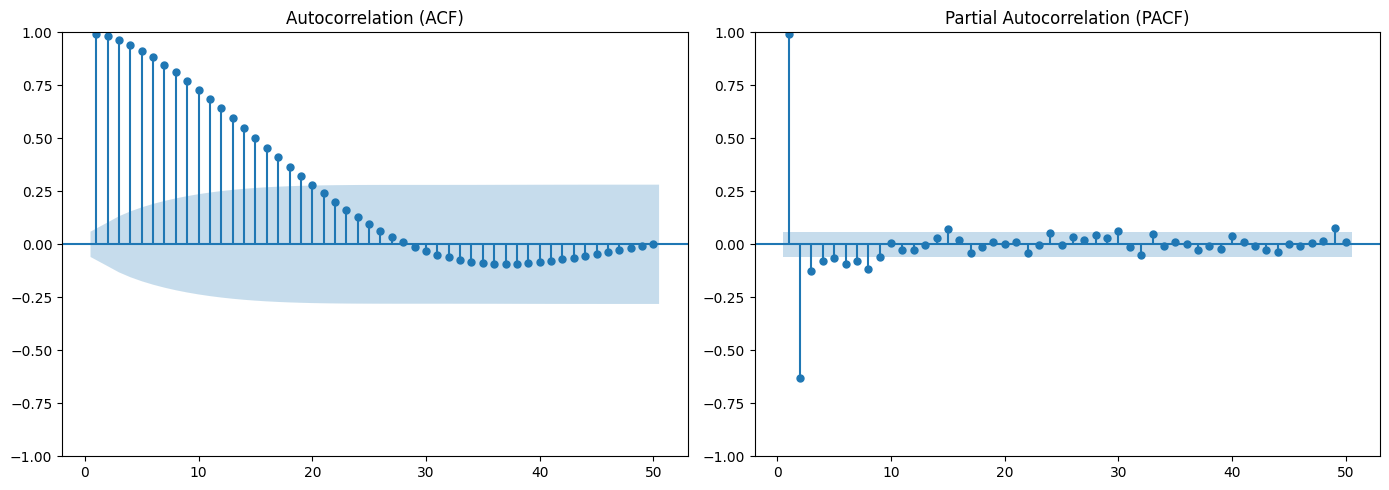

In [21]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# sequence.csv 불러오기
#df = pd.read_csv("/content/sequence.csv")

# value 시리즈 선택
values = df["value"]

# ACF, PACF 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ACF (자기상관)
plot_acf(values, ax=axes[0], lags=50, zero=False)
axes[0].set_title("Autocorrelation (ACF)")

# PACF (부분자기상관)
plot_pacf(values, ax=axes[1], lags=50, zero=False, method='ywm')
axes[1].set_title("Partial Autocorrelation (PACF)")

plt.tight_layout()
plt.show()